# 📊 Project Analisis Data: CerminSaku

## Business Questions:
- Kategori pengeluaran apa yang mengalami peningkatan terbesar (≥15%) pada pengguna selama periode Januari–Maret 2023, dan bagaimana hal tersebut memengaruhi total pengeluaran bulanan pengguna?
- Seberapa sering pengguna mengalami kondisi overbudget (pengeluaran > pemasukan) dalam periode 3 bulan, dan berapa rata-rata selisih defisit yang terjadi?
- Apakah terdapat perbedaan rata-rata pengeluaran harian antara hari kerja dan akhir pekan (≥20%), dan kategori apa yang paling berkontribusi terhadap perbedaan tersebut dalam periode 1 tahun?

# Menyiapkan Semua Library yang Dibutuhkan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Wrangling

## Gathering Data
Dataset diperoleh dari Kaggle: https://www.kaggle.com/datasets/ramyapintchy/personal-finance-data dengan sedikit modifikasi yaitu penambahan data dummy sejumlah 10.000 records untuk meningkatkan jumlah data serta mensimulasikan perilaku transaksi pengguna secara lebih realistis, sehingga analisis yang dilakukan menjadi lebih representatif.

In [2]:
df_raw = pd.read_csv('/content/Personal_Finance_Dataset_11500 (2).csv')
df_raw.head()

,Date,Transaction Description,Category,Amount,Type
0,2020-01-01,Water water mall mall phone investment.,Health & Fitness,620.39,Expense
1,2020-01-01,Loan insurance.,Rent,1384.51,Expense
2,2020-01-01,Health entertainment grocery fuel service pack...,Utilities,1546.58,Expense
3,2020-01-01,Fee charge.,Entertainment,567.55,Expense
4,2020-01-02,Score each.,Food & Drink,1485.69,Expense


In [3]:
df_raw.tail()

,Date,Transaction Description,Category,Amount,Type
11495,2024-12-31,Train project debit personal.,Salary,762.22,Income
11496,2024-12-31,Business service bill water savings.,Other,3160.39,Income
11497,2024-12-31,Bus interest service priority parking deal bal...,Salary,35.70,Income
11498,2024-12-31,Fee software water processed delivery savings.,Travel,1482.15,Expense
11499,2024-12-31,Loan equipment business household water.,Health & Fitness,1824.67,Expense


Berdasarkan dokumentasi dataset, tidak terdapat informasi mengenai mata uang pada kolom `Amount`. Oleh karena itu, dilakukan penyesuaian skala dengan asumsi bahwa 1 unit setara dengan Rp10.000 agar nilai transaksi lebih relevan dengan konteks pengguna di Indonesia. Penyesuaian ini dilakukan hanya untuk kebutuhan simulasi dan visualisasi pada proses analisis data.

## Assessing Data

In [4]:
#Mengecek Tipe Data
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     11500 non-null  object 
 1   Transaction Description  11500 non-null  object 
 2   Category                 11500 non-null  object 
 3   Amount                   11500 non-null  float64
 4   Type                     11500 non-null  object 
dtypes: float64(1), object(4)
memory usage: 449.3+ KB


Dari hasil di atas, terlihat bahwa kolom `Date` masih bertipe data `object`.
Hal ini menunjukkan bahwa data tanggal belum dalam format `datetime` sehingga perlu dikonversi pada tahap data cleaning agar dapat digunakan untuk analisis berbasis waktu.

In [5]:
#Mengecek Nilai Unik pada Kolom Type
df_raw['Type'].unique()

array(['Expense', 'Income'], dtype=object)

Berdasarkan hasil pengecekan di atas, nilai pada kolom `Type` sudah konsisten yaitu hanya terdiri dari `Expense` dan `Income`. Oleh karena itu, tidak diperlukan proses normalisasi atau pembersihan lebih lanjut pada kolom ini.

In [6]:
#Mengecek Nilai Unik pada Kolom Category
df_raw['Category'].unique()

array(['Health & Fitness', 'Rent', 'Utilities', 'Entertainment',
       'Food & Drink', 'Investment', 'Salary', 'Travel', 'Shopping',
       'Other'], dtype=object)

Berdasarkan hasil pengecekan di atas, nilai pada kolom `Category` sudah konsisten dan tidak ditemukan adanya inkonsistensi atau kesalahan penulisan. Oleh karena itu, tidak diperlukan proses pembersihan lebih lanjut pada kolom ini.

In [7]:
#Mengecek Missing Value
df_raw.isna().sum()

,0
Date,0
Transaction Description,0
Category,0
Amount,0
Type,0


Berdasarkan hasil pengecekan di atas, tidak ditemukan missing values pada seluruh kolom dalam dataset.

In [8]:
#Mengecek Duplikat
print("Jumlah duplikasi: ", df_raw.duplicated().sum())

Jumlah duplikasi:  0


Berdasarkan hasil pengecekan di atas, **tidak ditemukan adanya data duplikat** pada dataset. Oleh karena itu, tidak diperlukan proses penghapusan duplikasi pada tahap data cleaning.

In [9]:
#Mengecek Parameter Statistik
df_raw.groupby('Type')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Type,,,,,,,,
Expense,8321.0,1000.321273,478.039929,14.37,634.67,995.5,1360.060,1999.82
Income,3179.0,2107.710252,1218.940933,28.48,1103.92,1893.8,3029.915,4996.00


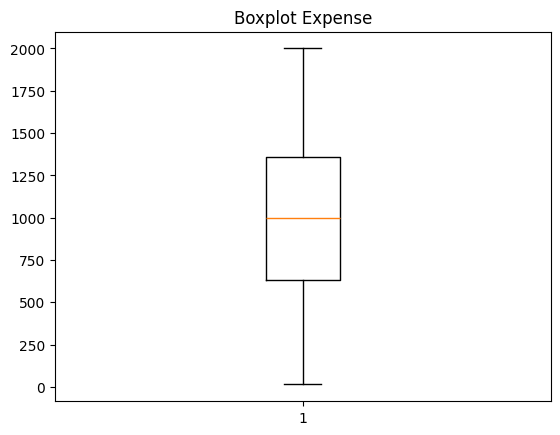

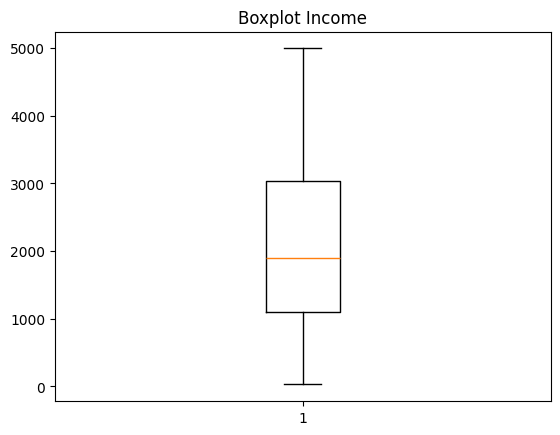

In [10]:
# Expense
plt.boxplot(df_raw[df_raw['Type']=='Expense']['Amount'])
plt.title("Boxplot Expense")
plt.show()

# Income
plt.boxplot(df_raw[df_raw['Type']=='Income']['Amount'])
plt.title("Boxplot Income")
plt.show()

Berdasarkan hasil analisis statistik dan visualisasi menggunakan boxplot, distribusi nilai pada kolom `Amount` untuk masing-masing tipe transaksi (`Expense` dan `Income`) sudah terlihat wajar dan tidak menunjukkan adanya outlier ekstrem yang mencurigakan. Hal ini menunjukkan bahwa data memiliki distribusi yang cukup stabil, sehingga tidak diperlukan penanganan outlier lebih lanjut pada tahap ini.

## Cleaning Data

In [11]:
# Membuat salinan dari raw data
df_clean = df_raw.copy()

In [12]:
# Mengubah tipe data kolom Date menjadi datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

# Cek kembali tipe data untuk memastikan sudah berubah
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     11500 non-null  datetime64[ns]
 1   Transaction Description  11500 non-null  object        
 2   Category                 11500 non-null  object        
 3   Amount                   11500 non-null  float64       
 4   Type                     11500 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 449.3+ KB


Melakukan konversi menggunakan fungsi `pd.to_datetime`. Langkah ini penting agar kolom tersebut dapat digunakan untuk analisis berbasis waktu secara akurat, dan hasil pengecekan melalui `df_clean.info()` mengonfirmasi bahwa tipe data telah berhasil diubah menjadi datetime64[ns].

In [13]:
# Scaling ke Rupiah
df_clean['Amount'] = df_clean['Amount'] * 10000

# Bulatkan & ubah ke integer
df_clean['Amount'] = df_clean['Amount'].round(0).astype(int)

# Rename kolom
df_clean = df_clean.rename(columns={'Amount': 'Amount (Rupiah)'})

Berdasarkan proses cleaning, kolom `Amount` telah disesuaikan skalanya ke Rupiah, kemudian dibulatkan dan diubah ke tipe integer lalu diubah nama kolom nya menjadi `Amount (Rupiah)`.

In [26]:
df_clean.head()

,Date,Transaction Description,Category,Amount (Rupiah),Type,Month,Day_Type
0,2020-01-01,Water water mall mall phone investment.,Health & Fitness,6203900,Expense,2020-01,Weekday
1,2020-01-01,Loan insurance.,Rent,13845100,Expense,2020-01,Weekday
2,2020-01-01,Health entertainment grocery fuel service pack...,Utilities,15465800,Expense,2020-01,Weekday
3,2020-01-01,Fee charge.,Entertainment,5675500,Expense,2020-01,Weekday
4,2020-01-02,Score each.,Food & Drink,14856900,Expense,2020-01,Weekday


In [14]:
# Export dataset yang sudah di cleaning
df_clean.to_csv('Personal_Finance_Dataset_Cleaned.csv', index=False)

# Exploratory Data Analysis (EDA)

In [15]:
# Explore
df_clean.describe(include="all")

,Date,Transaction Description,Category,Amount (Rupiah),Type
count,11500,11500,11500,1.150000e+04,11500
unique,NaN,11363,10,NaN,2
top,NaN,Invoice deal.,Rent,NaN,Expense
freq,NaN,3,1245,NaN,8321
mean,2022-07-07 09:52:24.208695808,NaN,NaN,1.306442e+07,NaN
min,2020-01-01 00:00:00,NaN,NaN,1.437000e+05,NaN
25%,2021-04-13 00:00:00,NaN,NaN,7.143950e+06,NaN
50%,2022-07-06 00:00:00,NaN,NaN,1.124810e+07,NaN
75%,2023-10-07 00:00:00,NaN,NaN,1.603768e+07,NaN
max,2024-12-31 00:00:00,NaN,NaN,4.996000e+07,NaN


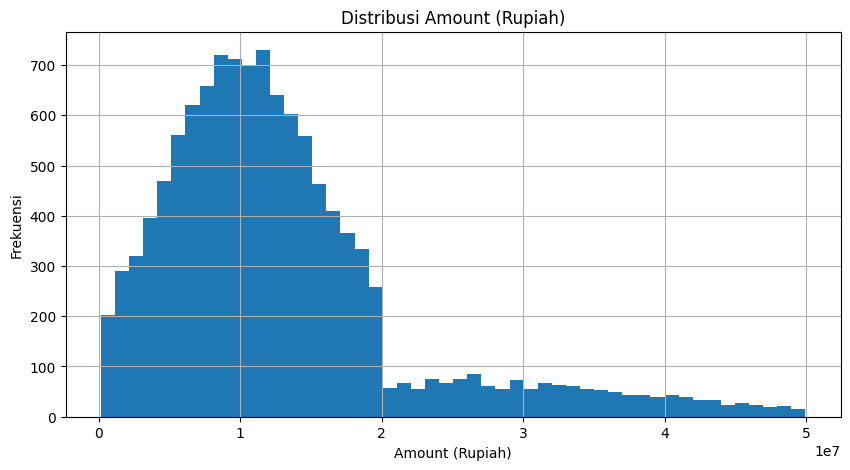

In [16]:
# Melihat distribusi data pada kolom Amount (Rupiah)
df_clean['Amount (Rupiah)'].hist(bins=50, figsize=(10, 5))
plt.title("Distribusi Amount (Rupiah)")
plt.xlabel("Amount (Rupiah)")
plt.ylabel("Frekuensi")
plt.show()

In [17]:
# Mengelompokkan data berdasarkan 'Type' dan menghitung agregasinya
df_clean.groupby(by="Type").agg({"Amount (Rupiah)": ["count", "sum", "mean", "max", "min"]})

Amount (Rupiah)                                             
                  count          sum          mean       max     min
Type                                                                
Expense            8321  83236733100  1.000321e+07  19998200  143700
Income             3179  67004108900  2.107710e+07  49960000  284800

In [18]:
# Memfilter khusus data pengeluaran
df_expense = df_clean[df_clean['Type'] == 'Expense']

# Mengelompokkan pengeluaran berdasarkan kategori dan mengurutkan dari yang terbesar
df_expense.groupby(by="Category").agg({"Amount (Rupiah)": ["count", "sum", "mean"]}).sort_values(by=("Amount (Rupiah)", "sum"), ascending=False)

Amount (Rupiah)                           
                           count          sum          mean
Category                                                   
Travel                      1217  12765783500  1.048955e+07
Rent                        1245  12424267300  9.979331e+06
Food & Drink                1146  12202869300  1.064823e+07
Entertainment               1172  12147810400  1.036503e+07
Utilities                   1220  11366034900  9.316422e+06
Health & Fitness            1162  11174183700  9.616337e+06
Shopping                    1159  11155784000  9.625353e+06

In [19]:
# Mengekstrak tahun-bulan untuk analisis tren bulanan
df_clean['Month'] = df_clean['Date'].dt.to_period('M')

# Mengekstrak tipe hari (Weekday jika Senin-Jumat, Weekend jika Sabtu-Minggu)
# dt.dayofweek bernilai 5 untuk Sabtu dan 6 untuk Minggu
df_clean['Day_Type'] = df_clean['Date'].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# Menampilkan data untuk memastikan kolom baru sudah terbentuk
df_clean.head()

,Date,Transaction Description,Category,Amount (Rupiah),Type,Month,Day_Type
0,2020-01-01,Water water mall mall phone investment.,Health & Fitness,6203900,Expense,2020-01,Weekday
1,2020-01-01,Loan insurance.,Rent,13845100,Expense,2020-01,Weekday
2,2020-01-01,Health entertainment grocery fuel service pack...,Utilities,15465800,Expense,2020-01,Weekday
3,2020-01-01,Fee charge.,Entertainment,5675500,Expense,2020-01,Weekday
4,2020-01-02,Score each.,Food & Drink,14856900,Expense,2020-01,Weekday


melihat total pengeluaran per kategori dari bulan ke bulan (khususnya Januari hingga Maret) untuk melihat kategori mana yang mengalami kenaikan signifikan.

In [20]:
# Filter data khusus untuk pengeluaran ('Expense') pada periode Januari - Maret 2023
df_filtered_months = df_clean[
    (df_clean['Type'] == 'Expense') &
    (df_clean['Date'] >= '2023-01-01') &
    (df_clean['Date'] <= '2023-03-31')]

# Mengelompokkan berdasarkan Kategori dan Bulan, lalu menjumlahkan totalnya
trend_pengeluaran = df_filtered_months.groupby(by=['Category', 'Month']).agg({
    'Amount (Rupiah)': 'sum'}).unstack()

trend_pengeluaran

Amount (Rupiah)                      
Month                    2023-01    2023-02    2023-03
Category                                              
Entertainment          268769700  213818000  207320300
Food & Drink           214687700  196392000   87139800
Health & Fitness       245463900  228902300  174781600
Rent                   208394400   83756600  200030900
Shopping               133281300  139031000  175687100
Travel                 232902200  143159600  141478300
Utilities              226764600  113140500  184629500

In [21]:
# Asumsi kolom ke-0 adalah Januari dan kolom ke-2 adalah Maret pada tabel trend_pengeluaran
januari = trend_pengeluaran.iloc[:, 0]
maret = trend_pengeluaran.iloc[:, -1] # Mengambil bulan terakhir di periode tersebut

# Menghitung persentase kenaikan
trend_pengeluaran['% Kenaikan'] = ((maret - januari) / januari) * 100

# Memfilter hanya kategori yang kenaikannya lebih dari 15%
kategori_signifikan = trend_pengeluaran[trend_pengeluaran['% Kenaikan'] > 15]

print("Kategori dengan kenaikan > 15%:")
kategori_signifikan[['% Kenaikan']]

Kategori dengan kenaikan > 15%:


,% Kenaikan
Month,NaT
Category,
Entertainment,NaN
Food & Drink,NaN
Health & Fitness,NaN
Rent,NaN
Shopping,31.816766
Travel,NaN
Utilities,NaN


Analisis Pola Harian Weekday vs Weekend

In [22]:
# Mengelompokkan data pengeluaran berdasarkan tipe hari
pola_harian = df_clean[df_clean['Type'] == 'Expense'].groupby(by='Day_Type').agg({
    'Amount (Rupiah)': ['count', 'mean', 'sum']})

pola_harian

Amount (Rupiah)                           
                   count          mean          sum
Day_Type                                           
Weekday             5999  9.933853e+06  59593185600
Weekend             2322  1.018241e+07  23643547500

Analisis Overbudget dan Defisit Bulanan

In [23]:
# 1. Mengelompokkan total per bulan berdasarkan tipe transaksi (Income vs Expense)
analisis_budget = df_clean.groupby(by=['Month', 'Type']).agg({
    'Amount (Rupiah)': 'sum'}).unstack()

# 2. Menghitung selisih (Pemasukan - Pengeluaran)
# Jika hasilnya negatif, artinya terjadi defisit (overbudget)
analisis_budget['Selisih'] = analisis_budget[('Amount (Rupiah)', 'Income')] - analisis_budget[('Amount (Rupiah)', 'Expense')]

# 3. Menentukan status bulanan
analisis_budget['Status'] = analisis_budget['Selisih'].apply(lambda x: 'Overbudget/Defisit' if x < 0 else 'Aman/Surplus')

analisis_budget

Amount (Rupiah)                Selisih              Status
Type            Expense      Income                               
Month                                                             
2020-01      1310698400   718724200 -591974200  Overbudget/Defisit
2020-02      1440449800  1225827600 -214622200  Overbudget/Defisit
2020-03      1192249700   923590600 -268659100  Overbudget/Defisit
2020-04      1307544000  1293927800  -13616200  Overbudget/Defisit
2020-05      1331389700  1225091600 -106298100  Overbudget/Defisit
2020-06      1448477500  1110950600 -337526900  Overbudget/Defisit
2020-07      1498201700   980055500 -518146200  Overbudget/Defisit
2020-08      1571629400   874708600 -696920800  Overbudget/Defisit
2020-09      1320117400  1041330300 -278787100  Overbudget/Defisit
2020-10      1300357400  1164492300 -135865100  Overbudget/Defisit
2020-11      1320865300  1180619400 -140245900  Overbudget/Defisit
2020-12      1403337800   885121200 -518216600  Overbudget/Defisit
2021-01      1583219600   873690300 -709529300  Overbudget/Defisit
2021-02      1239255200   816174200 -423081000  Overbudget/Defisit
2021-03      1494265900  1417530000  -76735900  Overbudget/Defisit
2021-04      1633006000   810107800 -822898200  Overbudget/Defisit
2021-05      1402050100   678837400 -723212700  Overbudget/Defisit
2021-06      1273067600   817042300 -456025300  Overbudget/Defisit
2021-07      1342019300  1151854700 -190164600  Overbudget/Defisit
2021-08      1328592200  1032085900 -296506300  Overbudget/Defisit
2021-09      1426054500  1009783400 -416271100  Overbudget/Defisit
2021-10      1532271200  1042942200 -489329000  Overbudget/Defisit
2021-11      1261899800  1205558400  -56341400  Overbudget/Defisit
2021-12      1258324000  1514426600  256102600        Aman/Surplus
2022-01      1580707600  1234135600 -346572000  Overbudget/Defisit
2022-02      1410248900  1249357900 -160891000  Overbudget/Defisit
2022-03      1499065600  1108810100 -390255500  Overbudget/Defisit
2022-04      1428687600  1148506200 -280181400  Overbudget/Defisit
2022-05      1458020000  1033774200 -424245800  Overbudget/Defisit
2022-06      1456361900  1284740900 -171621000  Overbudget/Defisit
2022-07      1438564000  1260404600 -178159400  Overbudget/Defisit
2022-08      1516769600  1234474200 -282295400  Overbudget/Defisit
2022-09      1275115500  1388737400  113621900        Aman/Surplus
2022-10      1439221000  1099219100 -340001900  Overbudget/Defisit
2022-11      1298031800  1279585600  -18446200  Overbudget/Defisit
2022-12      1446010800  1139667000 -306343800  Overbudget/Defisit
2023-01      1530263800  1228940800 -301323000  Overbudget/Defisit
2023-02      1118200000  1306675100  188475100        Aman/Surplus
2023-03      1171067500  1238317100   67249600        Aman/Surplus
2023-04      1311719300  1129763800 -181955500  Overbudget/Defisit
2023-05      1216858500  1225012700    8154200        Aman/Surplus
2023-06      1369336600   958471200 -410865400  Overbudget/Defisit
2023-07      1350006400   759071900 -590934500  Overbudget/Defisit
2023-08      1386841900  1018380400 -368461500  Overbudget/Defisit
2023-09      1597309800  1270545400 -326764400  Overbudget/Defisit
2023-10      1211962900  1067074500 -144888400  Overbudget/Defisit
2023-11      1564095100  1204507800 -359587300  Overbudget/Defisit
2023-12      1354575000  1022287700 -332287300  Overbudget/Defisit
2024-01      1505344100  1349555100 -155789000  Overbudget/Defisit
2024-02      1314278000  1322427500    8149500        Aman/Surplus
2024-03      1362869200  1317439900  -45429300  Overbudget/Defisit
2024-04      1333485100  1424622300   91137200        Aman/Surplus
2024-05      1202264300  1001953800 -200310500  Overbudget/Defisit
2024-06      1503673100  1064433100 -439240000  Overbudget/Defisit
2024-07      1441784300  1055182900 -386601400  Overbudget/Defisit
2024-08      1545737500  1131510800 -414226700  Overbudget/Defisit
2024-09      1233531400   992403300 -241128100  Overbud

mengitung berapa kali itu terjadi dan berapa rata-ratanya

In [24]:
# bulan-bulan yang mengalami defisit
data_defisit = analisis_budget[analisis_budget['Status'] == 'Overbudget/Defisit']

# Menghitung frekuensi dan rata-rata
frekuensi_defisit = len(data_defisit)
rata_rata_defisit = data_defisit['Selisih'].mean()

print(f"Pengguna mengalami overbudget sebanyak: {frekuensi_defisit} bulan")
print(f"Rata-rata defisit per bulannya adalah: {rata_rata_defisit:.2f}")

Pengguna mengalami overbudget sebanyak: 53 bulan
Rata-rata defisit per bulannya adalah: -320104043.40


Explore Statistik Deskriptif Keseluruhan:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,11500,NaN,NaN,NaN,2022-07-07 09:52:24.208695808,2020-01-01 00:00:00,2021-04-13 00:00:00,2022-07-06 00:00:00,2023-10-07 00:00:00,2024-12-31 00:00:00,NaN
Transaction Description,11500,11363,Invoice deal.,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,11500,10,Rent,1245,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount (Rupiah),11500.0,NaN,NaN,NaN,13064421.043478,143700.0,7143950.0,11248100.0,16037675.0,49960000.0,9062501.915921
Type,11500,2,Expense,8321,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month,11500,60,2024-01,215,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day_Type,11500,2,Weekday,8280,NaN,NaN,NaN,NaN,NaN,NaN,NaN




Distribusi data pada kolom nilai transaksi (Amount (Rupiah)):


,Amount (Rupiah)
count,11500.00
mean,13064421.04
std,9062501.92
min,143700.00
25%,7143950.00
50%,11248100.00
75%,16037675.00
max,49960000.00




Jumlah transaksi berdasarkan Kategori:


...



Analisis Overbudget (Status Surplus/Defisit per Bulan):


Amount (Rupiah)                Selisih              Status
Type            Expense      Income                               
Month                                                             
2020-01      1310698400   718724200 -591974200  Overbudget/Defisit
2020-02      1440449800  1225827600 -214622200  Overbudget/Defisit
2020-03      1192249700   923590600 -268659100  Overbudget/Defisit
2020-04      1307544000  1293927800  -13616200  Overbudget/Defisit
2020-05      1331389700  1225091600 -106298100  Overbudget/Defisit
2020-06      1448477500  1110950600 -337526900  Overbudget/Defisit
2020-07      1498201700   980055500 -518146200  Overbudget/Defisit
2020-08      1571629400   874708600 -696920800  Overbudget/Defisit
2020-09      1320117400  1041330300 -278787100  Overbudget/Defisit
2020-10      1300357400  1164492300 -135865100  Overbudget/Defisit
2020-11      1320865300  1180619400 -140245900  Overbudget/Defisit
2020-12      1403337800   885121200 -518216600  Overbudget/Defisit
2021-01      1583219600   873690300 -709529300  Overbudget/Defisit
2021-02      1239255200   816174200 -423081000  Overbudget/Defisit
2021-03      1494265900  1417530000  -76735900  Overbudget/Defisit
2021-04      1633006000   810107800 -822898200  Overbudget/Defisit
2021-05      1402050100   678837400 -723212700  Overbudget/Defisit
2021-06      1273067600   817042300 -456025300  Overbudget/Defisit
2021-07      1342019300  1151854700 -190164600  Overbudget/Defisit
2021-08      1328592200  1032085900 -296506300  Overbudget/Defisit
2021-09      1426054500  1009783400 -416271100  Overbudget/Defisit
2021-10      1532271200  1042942200 -489329000  Overbudget/Defisit
2021-11      1261899800  1205558400  -56341400  Overbudget/Defisit
2021-12      1258324000  1514426600  256102600        Aman/Surplus
2022-01      1580707600  1234135600 -346572000  Overbudget/Defisit
2022-02      1410248900  1249357900 -160891000  Overbudget/Defisit
2022-03      1499065600  1108810100 -390255500  Overbudget/Defisit
2022-04      1428687600  1148506200 -280181400  Overbudget/Defisit
2022-05      1458020000  1033774200 -424245800  Overbudget/Defisit
2022-06      1456361900  1284740900 -171621000  Overbudget/Defisit
2022-07      1438564000  1260404600 -178159400  Overbudget/Defisit
2022-08      1516769600  1234474200 -282295400  Overbudget/Defisit
2022-09      1275115500  1388737400  113621900        Aman/Surplus
2022-10      1439221000  1099219100 -340001900  Overbudget/Defisit
2022-11      1298031800  1279585600  -18446200  Overbudget/Defisit
2022-12      1446010800  1139667000 -306343800  Overbudget/Defisit
2023-01      1530263800  1228940800 -301323000  Overbudget/Defisit
2023-02      1118200000  1306675100  188475100        Aman/Surplus
2023-03      1171067500  1238317100   67249600        Aman/Surplus
2023-04      1311719300  1129763800 -181955500  Overbudget/Defisit
2023-05      1216858500  1225012700    8154200        Aman/Surplus
2023-06      1369336600   958471200 -410865400  Overbudget/Defisit
2023-07      1350006400   759071900 -590934500  Overbudget/Defisit
2023-08      1386841900  1018380400 -368461500  Overbudget/Defisit
2023-09      1597309800  1270545400 -326764400  Overbudget/Defisit
2023-10      1211962900  1067074500 -144888400  Overbudget/Defisit
2023-11      1564095100  1204507800 -359587300  Overbudget/Defisit
2023-12      1354575000  1022287700 -332287300  Overbudget/Defisit
2024-01      1505344100  1349555100 -155789000  Overbudget/Defisit
2024-02      1314278000  1322427500    8149500        Aman/Surplus
2024-03      1362869200  1317439900  -45429300  Overbudget/Defisit
2024-04      1333485100  1424622300   91137200        Aman/Surplus
2024-05      1202264300  1001953800 -200310500  Overbudget/Defisit
2024-06      1503673100  1064433100 -439240000  Overbudget/Defisit
2024-07      1441784300  1055182900 -386601400  Overbudget/Defisit
2024-08      1545737500  1131510800 -414226700  Overbudget/Defisit
2024-09      1233531400   992403300 -241128100  Overbud



Rata-rata Pengeluaran Berdasarkan Tipe Hari (Weekday vs Weekend):


Amount (Rupiah)                          
                   count         mean          sum
Day_Type                                          
Weekday             5999   9933853.24  59593185600
Weekend             2322  10182406.33  23643547500



Visualisasi Distribusi Jumlah Pengeluaran/Pemasukan:


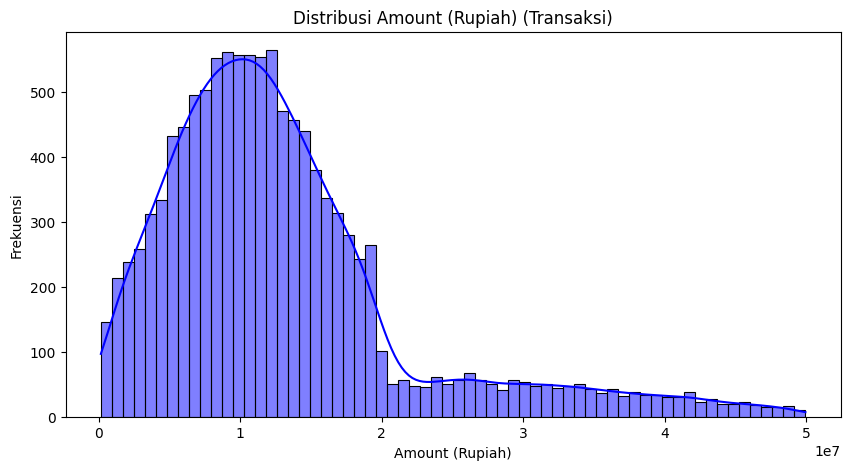

In [25]:
# Feature Engineering: Membuat kolom Bulan dan Tipe Hari (Weekday/Weekend) terlebih dahulu
df_clean['Month'] = df_clean['Date'].dt.to_period('M')
df_clean['Day_Type'] = df_clean['Date'].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

print("Explore Statistik Deskriptif Keseluruhan:")
display(df_clean.describe(include="all").T)

print("\n" + "="*70 + "\n")

# 1. Melihat parameter statistik dari kolom numerik (Amount (Rupiah))
print("Distribusi data pada kolom nilai transaksi (Amount (Rupiah)):")
display(df_clean['Amount (Rupiah)'].describe().round(2))

print("\n" + "="*70 + "\n")

# 2. Melihat distribusi data pada kolom kategorikal
print("Jumlah transaksi berdasarkan Kategori:")
display(df_clean['Category'].value_counts())

print("\n" + "="*70 + "\n")

# 3. Eksplorasi Tren Kategori Pengeluaran (Pertanyaan 1)
print("Total Pengeluaran Berdasarkan Kategori (Jan-Mar 2023):")
# Filter khusus pengeluaran di Jan-Mar 2023
df_q1 = df_clean[(df_clean['Type'] == 'Expense') & (df_clean['Date'] >= '2023-01-01') & (df_clean['Date'] <= '2023-03-31')]
display(df_q1.groupby(by=['Category', 'Month']).agg({
    'Amount (Rupiah)': 'sum'
}).unstack().round(2))

print("\n" + "="*70 + "\n")

# 4. Eksplorasi Analisis Overbudget (Pertanyaan 2)
print("Analisis Overbudget (Status Surplus/Defisit per Bulan):")
# Hitung total Income dan Expense per bulan
analisis_budget = df_clean.groupby(by=['Month', 'Type']).agg({'Amount (Rupiah)': 'sum'}).unstack()
# Buat kolom selisih (Income - Expense)
analisis_budget['Selisih'] = analisis_budget[('Amount (Rupiah)', 'Income')] - analisis_budget[('Amount (Rupiah)', 'Expense')]
# Beri label status
analisis_budget['Status'] = analisis_budget['Selisih'].apply(lambda x: 'Overbudget/Defisit' if x < 0 else 'Aman/Surplus')
display(analisis_budget.round(2))

print("\n" + "="*70 + "\n")

# 5. Eksplorasi Rata-rata Pengeluaran Berdasarkan Hari (Pertanyaan 3)
print("Rata-rata Pengeluaran Berdasarkan Tipe Hari (Weekday vs Weekend):")
# Filter khusus expense, lalu kelompokkan berdasarkan Day_Type
display(df_clean[df_clean['Type'] == 'Expense'].groupby(by="Day_Type").agg({
    "Amount (Rupiah)": ["count", "mean", "sum"]
}).round(2))

print("\n" + "="*70 + "\n")

# 6. Visualisasi Distribusi Amount (Rupiah)
print("Visualisasi Distribusi Jumlah Pengeluaran/Pemasukan:")
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['Amount (Rupiah)'], kde=True, color='blue')
plt.title("Distribusi Amount (Rupiah) (Transaksi)")
plt.xlabel("Amount (Rupiah)")
plt.ylabel("Frekuensi")
plt.show()

# Feature Engineering

# Data Visualization & Explanatory Analysis